# Three-Class Dual Steering Scratchpad

A minimal version of `dual_steering_scratch.ipynb` with exactly three classes and a three-dimensional activation space.

The point is to make all three spaces visually honest:

- **Primal space**: raw activations `h ∈ R^3`.
- **Dual probe-vector space**: convex combinations `sum_c p(c|h) W_c ∈ R^3`.
- **Probability simplex**: probability vectors `p(c|h) ∈ Δ²`, shown directly in `(p0, p1, p2)` coordinates.

This notebook intentionally keeps the setup small so we can reason step by step.

In [1]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import Tensor

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
print(f"device={DEVICE} dtype={DTYPE}")

device=cpu dtype=torch.float32


## 1. Synthetic 3-Class Activation Cloud

We use `C=3` classes and `D=3` activation dimensions.

The class centroids are the vertices of a triangle in the plane `z=0`, with mild Gaussian noise in all three dimensions. This means the primal activation space can be plotted directly in 3D without PCA.

In [2]:
C = 3
D = 3
N_PER_CLASS = 250
NOISE_STD = 0.25
CLASS_NAMES = ["A", "B", "C"]

class_centroids = torch.tensor(
    [
        [2.0, 0.0, 0.0],
        [-1.0, 1.732, 0.0],
        [-1.0, -1.732, 0.0],
    ],
    device=DEVICE,
    dtype=DTYPE,
)

labels = torch.arange(C, device=DEVICE).repeat_interleave(N_PER_CLASS)
H = class_centroids[labels] + NOISE_STD * torch.randn(C * N_PER_CLASS, D, device=DEVICE, dtype=DTYPE)

print(f"H: {tuple(H.shape)}")
print(f"centroids:\n{class_centroids.cpu()}")

H: (750, 3)
centroids:
tensor([[ 2.0000,  0.0000,  0.0000],
        [-1.0000,  1.7320,  0.0000],
        [-1.0000, -1.7320,  0.0000]])


## 2. Train a No-Bias Linear Probe

The probe has weights `W ∈ R^{3×3}`. Since `D=3`, the probe vectors themselves can be plotted directly in 3D too.

In [3]:
def train_probe(H: Tensor, labels: Tensor, *, n_steps: int = 1500, lr: float = 0.05) -> tuple[Tensor, dict]:
    W = torch.zeros(C, D, device=H.device, dtype=H.dtype, requires_grad=True)
    torch.nn.init.normal_(W, std=0.2)
    opt = torch.optim.Adam([W], lr=lr, weight_decay=1e-4)

    for step in range(n_steps):
        logits = H @ W.T
        loss = F.cross_entropy(logits, labels)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if step % 500 == 0:
            acc = logits.argmax(dim=-1).eq(labels).float().mean().item()
            print(f"step={step:4d} loss={loss.item():.4f} acc={acc:.3f}")

    with torch.no_grad():
        logits = H @ W.T
        acc = logits.argmax(dim=-1).eq(labels).float().mean().item()
    return W.detach(), {"train_acc": acc, "loss": float(loss.item())}


W, probe_metrics = train_probe(H, labels)
print("probe metrics:", probe_metrics)
print("W:\n", W.cpu())

step=   0 loss=1.0189 acc=0.112


step= 500 loss=0.0014 acc=1.000


step=1000 loss=0.0007 acc=1.000


probe metrics: {'train_acc': 1.0, 'loss': 0.0004890980198979378}
W:
 tensor([[ 2.4568, -0.0177,  0.0262],
        [-2.1707,  2.7350, -0.0802],
        [-2.1107, -2.5882,  0.0539]])


## 3. Maps Between Spaces

For a primal activation `h`, the probe gives a probability vector:

```python
p = softmax(W h)
```

We visualize two derived spaces:

- **Dual-vector point**: `sum_c p_c W_c`, a convex combination of the probe vectors.
- **Simplex point**: `p` itself, shown as `(p_A, p_B, p_C)`.

In [4]:
def probe_softmax(h: Tensor, W: Tensor) -> Tensor:
    return F.softmax(h @ W.T, dim=-1)


def class_diff(W: Tensor, source: int, target: int) -> Tensor:
    return W[target] - W[source]


def dual_vector(h: Tensor, W: Tensor) -> Tensor:
    """Map primal activations to convex combinations of probe vectors."""
    p = probe_softmax(h, W)
    return p @ W


def activation_from_probe_probs(q: Tensor, W: Tensor, *, anchor: Tensor, ridge: float = 1.0, eps: float = 1e-4) -> Tensor:
    """Ridge inverse from desired probe probabilities back to a primal activation.

    Since softmax logits are invariant to additive constants, solve in centered-logit space.
    The anchor term picks a nearby representative from the underdetermined solution set.
    """
    q = q.clamp_min(eps)
    q = q / q.sum()
    z = q.log()
    z = z - z.mean()

    A = W - W.mean(dim=0, keepdim=True)
    I = torch.eye(W.shape[1], device=W.device, dtype=W.dtype)
    rhs = A.T @ (z - A @ anchor)
    update = torch.linalg.solve(A.T @ A + ridge * I, rhs)
    return anchor + update

## 4. Define Paths

We keep two paths:

1. **Additive probe path**: starts at the source centroid and repeatedly adds `eta * (W_target - W_source)`.
2. **Simplex path**: linearly interpolates probability vectors in the simplex, then maps each probability vector back to a primal activation via the ridge inverse.

The simplex path is the one we want to inspect carefully.

In [5]:
def additive_probe_path(h0: Tensor, W: Tensor, *, source: int, target: int, n_steps: int, eta: float) -> Tensor:
    beta = class_diff(W, source, target)
    alphas = torch.arange(n_steps, device=h0.device, dtype=h0.dtype)
    return h0.unsqueeze(0) + (eta * alphas).unsqueeze(1) * beta.unsqueeze(0)


def simplex_probe_path(
    h0: Tensor,
    h_target: Tensor,
    W: Tensor,
    *,
    n_steps: int,
    eta: float = 1.0,
    ridge: float = 1.0,
    eps: float = 1e-4,
    temperature: float = 2.0,
    pin_endpoints: bool = True,
) -> Tensor:
    q0 = F.softmax((h0 @ W.T) / temperature, dim=-1)
    q1 = F.softmax((h_target @ W.T) / temperature, dim=-1)
    alphas = torch.linspace(0.0, eta, n_steps, device=h0.device, dtype=h0.dtype)

    waypoints = []
    for i, a in enumerate(alphas):
        if pin_endpoints and i == 0:
            waypoints.append(h0.clone())
            continue
        if pin_endpoints and abs(float(a.item()) - 1.0) < 1e-7:
            waypoints.append(h_target.clone())
            continue

        q = (1.0 - a) * q0 + a * q1
        q = q.clamp_min(eps)
        q = q / q.sum()
        anchor = h0 + a * (h_target - h0)
        waypoints.append(activation_from_probe_probs(q, W, anchor=anchor, ridge=ridge, eps=eps))

    return torch.stack(waypoints)

## 5. Build Paths and Print Diagnostics

The source/target below are `A → B`. Adjust `SOURCE` and `TARGET` to inspect another pair.

In [6]:
@dataclass
class PathResult:
    label: str
    waypoints: Tensor


SOURCE, TARGET = 0, 1  # A -> B
h_start = class_centroids[SOURCE]
h_target = class_centroids[TARGET]

ADDITIVE_N_STEPS = 12
ADDITIVE_ETA = 0.08

SIMPLEX_N_STEPS = 80
SIMPLEX_ETA = 1.0
SIMPLEX_RIDGE = 1.0
SIMPLEX_EPS = 1e-4
SIMPLEX_TEMPERATURE = 2.0

add_path = PathResult(
    "additive_probe_path",
    additive_probe_path(h_start, W, source=SOURCE, target=TARGET, n_steps=ADDITIVE_N_STEPS, eta=ADDITIVE_ETA),
)
simplex_path = PathResult(
    "simplex_probe_path",
    simplex_probe_path(
        h_start,
        h_target,
        W,
        n_steps=SIMPLEX_N_STEPS,
        eta=SIMPLEX_ETA,
        ridge=SIMPLEX_RIDGE,
        eps=SIMPLEX_EPS,
        temperature=SIMPLEX_TEMPERATURE,
        pin_endpoints=True,
    ),
)
paths = [add_path, simplex_path]

for result in paths:
    probs = probe_softmax(result.waypoints, W)
    print(f"{result.label}: {tuple(result.waypoints.shape)}")
    print("  start probs:", {CLASS_NAMES[i]: round(probs[0, i].item(), 3) for i in range(C)})
    print("  end probs:  ", {CLASS_NAMES[i]: round(probs[-1, i].item(), 3) for i in range(C)})
    print("  step max:", round((result.waypoints[1:] - result.waypoints[:-1]).norm(dim=1).max().item(), 3))

additive_probe_path: (12, 3)
  start probs: {'A': 1.0, 'B': 0.0, 'C': 0.0}
  end probs:   {'A': 0.0, 'B': 1.0, 'C': 0.0}
  step max: 0.431
simplex_probe_path: (80, 3)
  start probs: {'A': 1.0, 'B': 0.0, 'C': 0.0}
  end probs:   {'A': 0.0, 'B': 1.0, 'C': 0.0}
  step max: 1.038


## 6. Fully 3D Visualization

Because there are only three activation dimensions and three classes:

- primal space is shown directly as `(h₁, h₂, h₃)`;
- dual-vector space is shown directly as `(dual₁, dual₂, dual₃)`;
- simplex space is shown directly as `(p_A, p_B, p_C)`.

The stacked probability plots below show the same simplex trajectory as mass over classes.

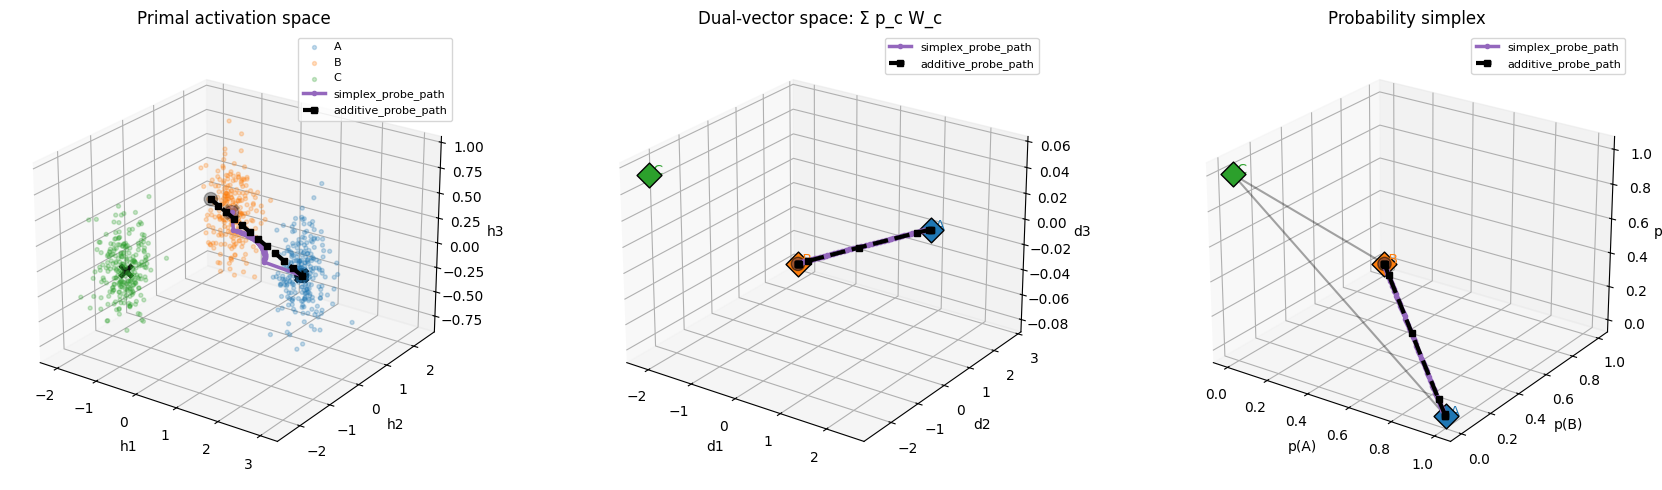

In [7]:
def _path_style(label: str) -> dict:
    """Consistent path styling; make additive visible when curves overlap."""
    if "additive" in label:
        return {"color": "black", "linestyle": "--", "marker": "s", "lw": 3.0, "markersize": 5, "zorder": 20}
    if "simplex" in label:
        return {"color": "tab:purple", "linestyle": "-", "marker": "o", "lw": 2.5, "markersize": 3, "zorder": 10}
    return {"linestyle": "-", "marker": "o", "lw": 2.0, "markersize": 3, "zorder": 5}


def plot_three_class_spaces(paths: list[PathResult]) -> None:
    colors = ["tab:blue", "tab:orange", "tab:green"]

    # Draw non-additive paths first, then additive last so overlap is visible.
    paths_to_draw = sorted(paths, key=lambda p: "additive" in p.label)

    fig = plt.figure(figsize=(18, 5))
    axes = [fig.add_subplot(1, 3, i + 1, projection="3d") for i in range(3)]

    # Primal activation space.
    ax = axes[0]
    labels_np = labels.detach().cpu().numpy()
    H_np = H.detach().cpu().numpy()
    for c in range(C):
        mask = labels_np == c
        ax.scatter(H_np[mask, 0], H_np[mask, 1], H_np[mask, 2], s=8, alpha=0.25, color=colors[c], label=CLASS_NAMES[c])
    cent_np = class_centroids.detach().cpu().numpy()
    ax.scatter(cent_np[:, 0], cent_np[:, 1], cent_np[:, 2], s=160, marker="X", color="black", edgecolors="white")
    for result in paths_to_draw:
        style = _path_style(result.label)
        pts = result.waypoints.detach().cpu().numpy()
        ax.plot(
            pts[:, 0], pts[:, 1], pts[:, 2],
            lw=style["lw"], marker=style["marker"], markersize=style["markersize"],
            linestyle=style["linestyle"], color=style.get("color"), label=result.label,
            zorder=style["zorder"],
        )
        ax.scatter(pts[[0, -1], 0], pts[[0, -1], 1], pts[[0, -1], 2], s=90, edgecolors="black", color=style.get("color"), zorder=style["zorder"])
    ax.set_title("Primal activation space")
    ax.set_xlabel("h1")
    ax.set_ylabel("h2")
    ax.set_zlabel("h3")
    ax.legend(fontsize=8)

    # Dual-vector space.
    ax = axes[1]
    W_np = W.detach().cpu().numpy()
    for c in range(C):
        ax.scatter(W_np[c, 0], W_np[c, 1], W_np[c, 2], s=160, marker="D", color=colors[c], edgecolors="black")
        ax.text(W_np[c, 0], W_np[c, 1], W_np[c, 2], f" {CLASS_NAMES[c]}", color=colors[c], fontsize=10)
    for result in paths_to_draw:
        style = _path_style(result.label)
        dpts = dual_vector(result.waypoints, W).detach().cpu().numpy()
        ax.plot(
            dpts[:, 0], dpts[:, 1], dpts[:, 2],
            lw=style["lw"], marker=style["marker"], markersize=style["markersize"],
            linestyle=style["linestyle"], color=style.get("color"), label=result.label,
            zorder=style["zorder"],
        )
        ax.scatter(dpts[[0, -1], 0], dpts[[0, -1], 1], dpts[[0, -1], 2], s=90, edgecolors="black", color=style.get("color"), zorder=style["zorder"])
    ax.set_title("Dual-vector space: Σ p_c W_c")
    ax.set_xlabel("d1")
    ax.set_ylabel("d2")
    ax.set_zlabel("d3")
    ax.legend(fontsize=8)

    # Probability simplex in direct p_A, p_B, p_C coordinates.
    ax = axes[2]
    eye = torch.eye(C).numpy()
    for c in range(C):
        ax.scatter(eye[c, 0], eye[c, 1], eye[c, 2], s=160, marker="D", color=colors[c], edgecolors="black")
        ax.text(eye[c, 0], eye[c, 1], eye[c, 2], f" {CLASS_NAMES[c]}", color=colors[c], fontsize=10)
    # Triangle edges.
    tri = np.vstack([eye, eye[0:1]])
    ax.plot(tri[:, 0], tri[:, 1], tri[:, 2], color="black", alpha=0.35)
    for result in paths_to_draw:
        style = _path_style(result.label)
        probs = probe_softmax(result.waypoints, W).detach().cpu().numpy()
        ax.plot(
            probs[:, 0], probs[:, 1], probs[:, 2],
            lw=style["lw"], marker=style["marker"], markersize=style["markersize"],
            linestyle=style["linestyle"], color=style.get("color"), label=result.label,
            zorder=style["zorder"],
        )
        ax.scatter(probs[[0, -1], 0], probs[[0, -1], 1], probs[[0, -1], 2], s=90, edgecolors="black", color=style.get("color"), zorder=style["zorder"])
    ax.set_title("Probability simplex")
    ax.set_xlabel("p(A)")
    ax.set_ylabel("p(B)")
    ax.set_zlabel("p(C)")
    ax.legend(fontsize=8)

    for ax in axes:
        ax.view_init(elev=24, azim=-55)

    fig.tight_layout()
    plt.show()


plot_three_class_spaces(paths)


## 7. Stacked Probability Mass

This is the same simplex information as the 3D simplex plot, shown as a stacked mass decomposition over trajectory fraction.

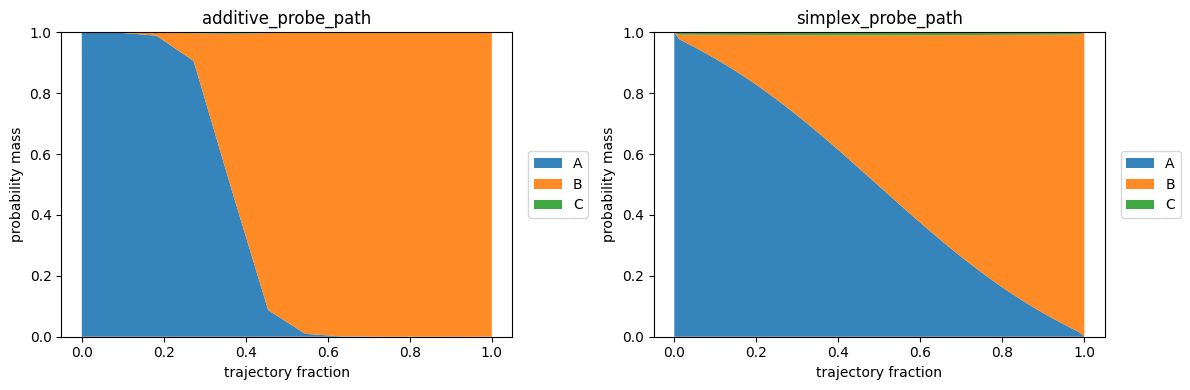

In [8]:
def plot_stacked_probabilities(paths: list[PathResult]) -> None:
    colors = ["tab:blue", "tab:orange", "tab:green"]
    fig, axes = plt.subplots(1, len(paths), figsize=(6 * len(paths), 4), squeeze=False)
    axes = axes[0]

    for ax, result in zip(axes, paths):
        probs = probe_softmax(result.waypoints, W).detach().cpu().numpy()
        x = np.linspace(0.0, 1.0, probs.shape[0])
        ax.stackplot(x, probs.T, labels=CLASS_NAMES, colors=colors, alpha=0.9)
        ax.set_title(result.label)
        ax.set_xlabel("trajectory fraction")
        ax.set_ylabel("probability mass")
        ax.set_ylim(0.0, 1.0)
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

    fig.tight_layout()
    plt.show()


plot_stacked_probabilities(paths)